# Mini Project 1: Exploratory Data Analysis

## Introduction

This dataset contains customer analytics information related to demographics,
income levels, purchasing behavior, and online activity.

Each row represents one individual customer and their shopping characteristics.

The goal of this analysis is to understand customer behavior patterns,
clean the data, and discover meaningful insights using Exploratory Data Analysis (EDA).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("D:\Mini_project\customer_analytics.csv")

In [5]:
df.head()

,CustomerID,Age,Gender,City,Education,MaritalStatus,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,PreferredDevice,LastPurchaseAmount
0,1001,49,Male,Pune,Masters,Single,82953.0,66,23,19,9,2,Laptop,3944
1,1002,44,Male,Pune,PhD,Single,60610.0,56,22,1,23,3,Desktop,3885
2,1003,42,Male,Mumbai,Bachelors,Single,35501.0,44,18,10,29,3,Laptop,3247
3,1004,36,Female,Mumbai,Masters,Married,99312.0,36,10,12,21,3,Mobile,2028
4,1005,23,Male,Pune,Masters,Married,46980.0,56,1,18,9,3,Tablet,1100


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            255 non-null    int64  
 1   Age                   255 non-null    int64  
 2   Gender                255 non-null    object 
 3   City                  255 non-null    object 
 4   Education             243 non-null    object 
 5   MaritalStatus         255 non-null    object 
 6   AnnualIncome          243 non-null    float64
 7   SpendingScore         255 non-null    int64  
 8   YearsEmployed         255 non-null    int64  
 9   PurchaseFrequency     255 non-null    int64  
 10  OnlineVisitsPerMonth  255 non-null    int64  
 11  ReturnedItems         255 non-null    int64  
 12  PreferredDevice       255 non-null    object 
 13  LastPurchaseAmount    255 non-null    int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 28.0+ KB


The dataset contains 255 customer records and 14 features.
The dataset includes numerical and categorical attributes such as Age,
Annual Income, Spending Score, and Preferred Device.

In [7]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
count,255.000000,255.000000,243.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.00000
mean,1126.941176,37.729412,74499.901235,45.721569,14.682353,11.568627,16.078431,1.858824,2795.07451
std,72.397256,9.767842,43939.855655,17.869522,9.651664,7.077899,7.909536,1.409917,1328.77241
min,1001.000000,21.000000,16062.000000,5.000000,1.000000,1.000000,3.000000,0.000000,566.00000
25%,1064.500000,29.000000,56353.000000,34.500000,6.000000,5.000000,10.000000,1.000000,1542.50000
50%,1128.000000,38.000000,69629.000000,47.000000,15.000000,11.000000,16.000000,2.000000,2705.00000
75%,1190.500000,46.000000,84030.500000,57.500000,23.000000,18.000000,23.000000,3.000000,4001.00000
max,1250.000000,54.000000,474327.000000,95.000000,34.000000,24.000000,29.000000,4.000000,4996.00000


The statistical summary shows the distribution of numerical variables.
Average customer age is around 37 years.
Spending scores and income values vary significantly among customers.

In [8]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

Education → 12 missing
AnnualIncome → 12 missing

In [15]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])
df['AnnualIncome'] = df['AnnualIncome'].fillna(df['AnnualIncome'].median())

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df = df.drop_duplicates()

## Data Cleaning Decisions

- Missing values were detected in Education and AnnualIncome columns.
- Education was filled using mode because it is categorical data.
- AnnualIncome was filled using median to avoid influence of extreme values.
- Duplicate rows were removed to ensure accurate analysis.

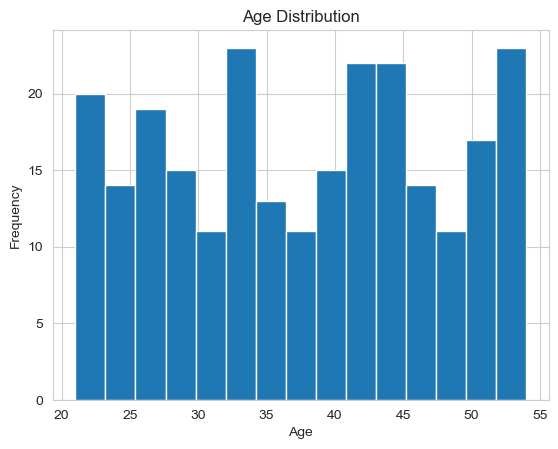

In [18]:
plt.hist(df['Age'], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Most customers fall between ages 25 and 50,
indicating a middle-aged customer base.

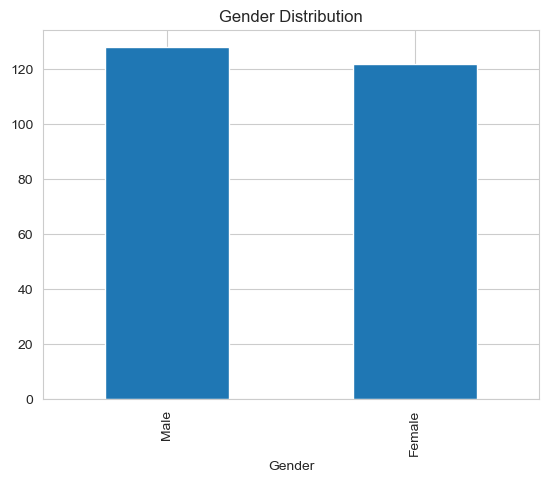

In [19]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

Male and female customers are almost equally represented,
showing balanced gender participation.

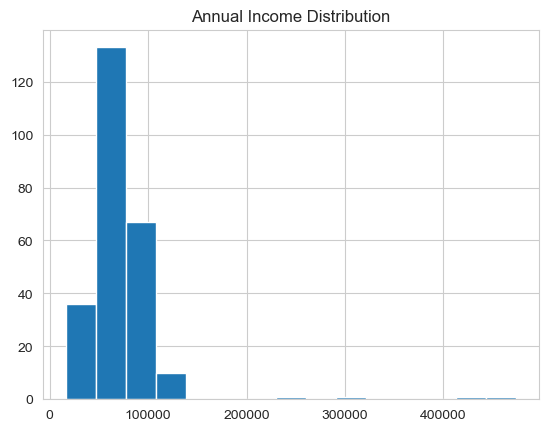

In [20]:
plt.hist(df['AnnualIncome'], bins=15)
plt.title("Annual Income Distribution")
plt.show()

Most customers earn within a moderate income range,
while few high-income outliers are present.

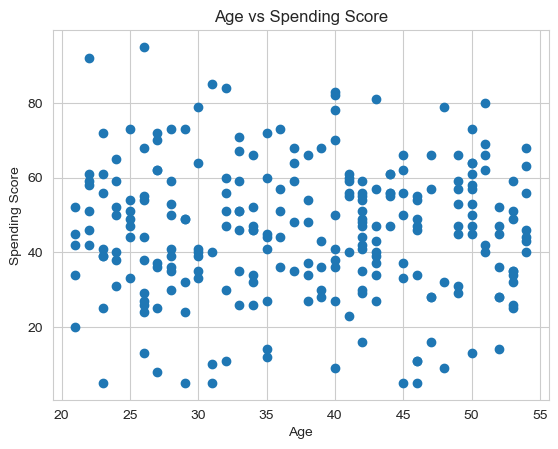

In [21]:
plt.scatter(df['Age'], df['SpendingScore'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()

Spending score does not strongly depend on age,
indicating purchasing behavior varies across all age groups.

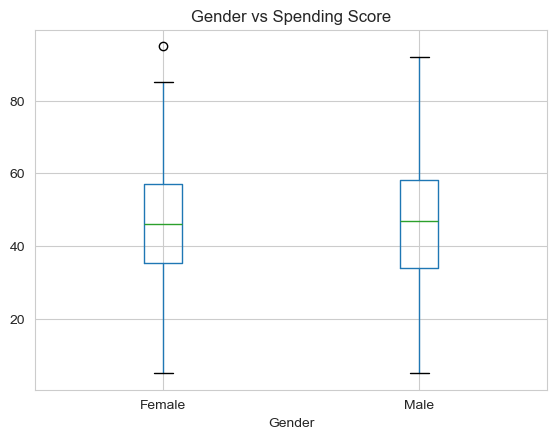

In [22]:
df.boxplot(column='SpendingScore', by='Gender')
plt.title("Gender vs Spending Score")
plt.suptitle("")
plt.show()

Both genders show similar spending patterns,
with only slight variation in median spending scores.

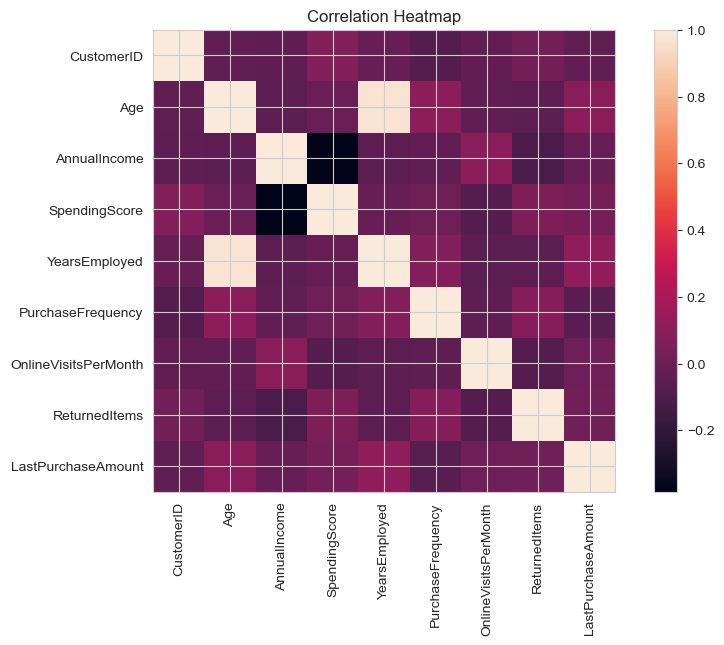

In [23]:
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between numerical variables.
Years Employed and Age show positive correlation,
while spending behavior appears weakly correlated with income.

## Executive Summary

1. The majority of customers belong to the 25–50 age group, indicating the business primarily serves middle-aged consumers.

2. Spending Score shows weak correlation with income and age, suggesting purchasing behavior depends on factors beyond demographics.

3. Gender distribution and spending patterns are balanced, meaning marketing strategies can target both genders equally.